# An EXP simulation using pyEXP from a notebook: a disk-halo simulation with velocity coefficients

This example uses a velocity field coefficient from an EXP simulation similar to the Disk Halo case but with higher particle number.

The final section of this notebook uses k3d for three-dimensional respresentation of contours. If you do not have k3d, you will need to pip install k3d if you would like to see the three-dimensional views. The Docker container has k3d preinstalled.

We begin by importing `pyEXP` and friends and setting the working directory.

In [1]:
import os
import yaml
import pyEXP
import numpy as np
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = [12, 9]

os.chdir('DiskHalo')

# Print the current working directory for reference
print(os.getcwd())

/home/weinberg/Projects/pyEXP-examples/Tutorials/EXP/DiskHalo


## The simulation configuration

This notebook uses velocity coefficients from the simulation defined in `veltest.yml`.  We are not going to run that here--it would take very long on a laptop or workstation--but we have provided the output files and configuration in this directory for reference.

We will import the YAML file to get the configuration for the velocity bases next...

In [2]:
with open('veltest.yml', 'r') as f:
    yaml_db = yaml.load(f, Loader=yaml.FullLoader)

# The 0 index force is the halo and the 1 index force is the disk, e.g.:
for i in range(2):
    print('Index {} is {}'.format(i, yaml_db['Components'][i]['name']))

Index 0 is dark
Index 1 is star


## Make the basis and look at some basis functions

In [3]:
vel_config = yaml_db['Output'][5]
vel_config['id'] = 'velocity'
# remove unwanted keys
if 'nint' in vel_config['parameters'].keys(): del vel_config['parameters']['nint']
if 'name' in vel_config['parameters'].keys(): del vel_config['parameters']['name']
print(yaml.dump(vel_config))

id: velocity
parameters:
  ascl: 0.014
  delta: 0.0002
  dof: 2
  lmax: 4
  model: expon
  nmax: 16
  rmapping: 0.014
  rmax: 0.14
  rmin: 0.0001



In [4]:
# Make the velocity basis
vel_basis  = pyEXP.basis.Basis.factory(yaml.dump(vel_config))

FieldBasis::orthoTest: worst=2.45095e-15


In [5]:
logxmin = -4
logxmax = -1
numgrid = 2000

vel_grid  = vel_basis.getBasis(logxmin, logxmax, numgrid)

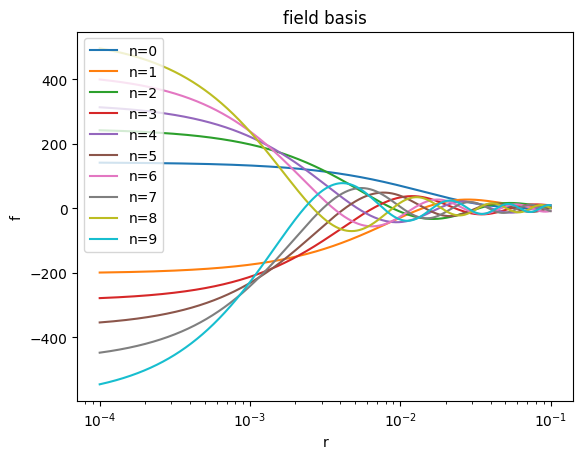

In [6]:
# Make a logarithmically space grid in radius
#
r = np.linspace(logxmin, logxmax, numgrid)
r = np.power(10.0, r)
  
for n in range(10):
    plt.semilogx(r, vel_grid[n], '-', label="n={}".format(n))
plt.xlabel('r')
plt.ylabel('f')
plt.title('field basis')
plt.legend()
plt.show()

## Visualizing the disk velocity fields

In [7]:
# read in the coefficients
vcoeffile = 'velcoef.star.run2'
vcoefs0 = pyEXP.coefs.Coefs.factory(vcoeffile, 1)
vcoefs  = vcoefs0.deepcopy()
times   = vcoefs0.Times()

### Plot some coefficients

(7, 5, 16, 21)


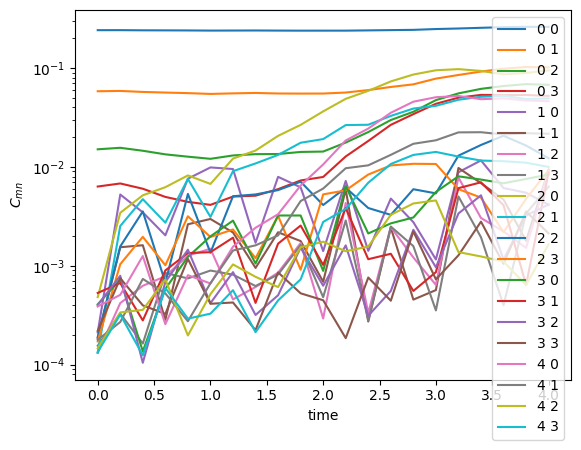

In [8]:
data = vcoefs0.getAllCoefs()
print(data.shape)
for m in range(0, data.shape[1]):
    for n in range(4):
        plt.semilogy(times, np.abs(data[0, m, n, :]), label='{} {}'.format(m, n))

plt.xlabel('time')
plt.ylabel(r'$C_{mn}$')
plt.legend()
plt.show()

## Plot the aggregated coefficient amplitude

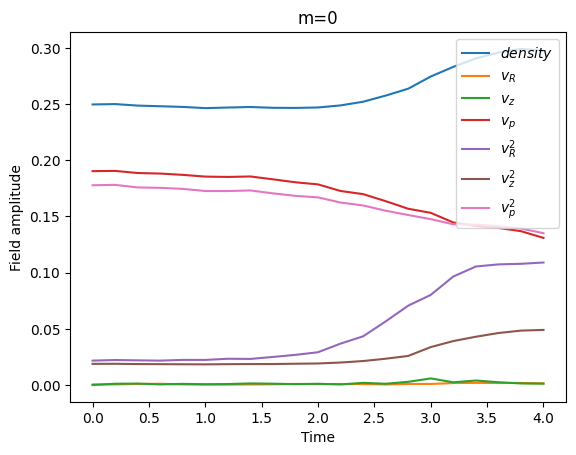

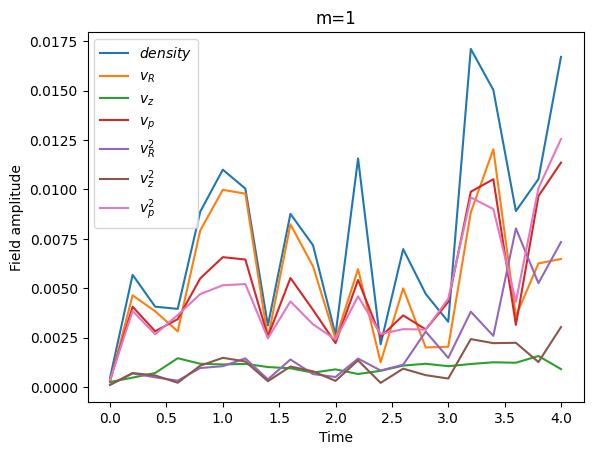

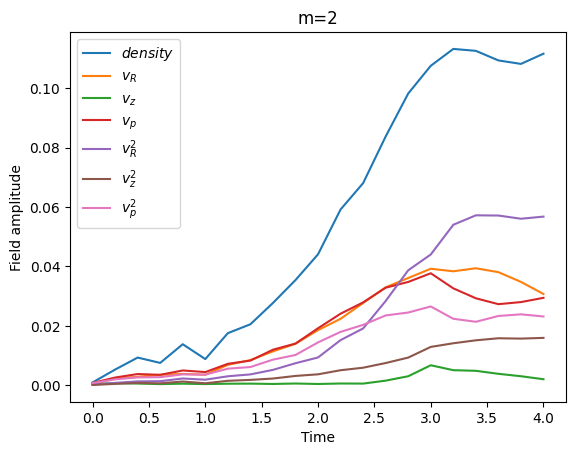

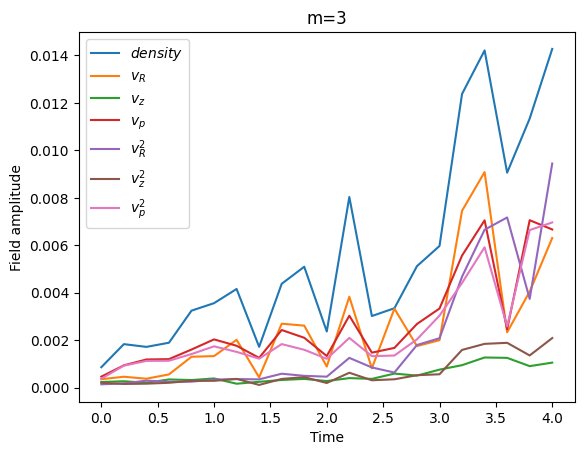

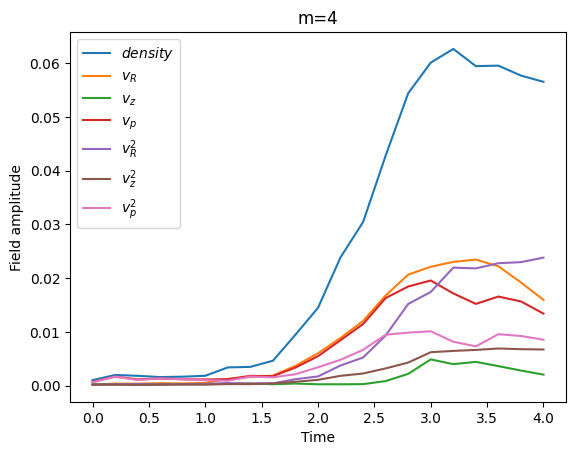

In [9]:
data = vcoefs0.getAllCoefs()
labels = vel_basis.getFieldLabels()

for m in range(0, data.shape[1]):
    for i in range(0, data.shape[0]):
        sum = np.zeros(data.shape[3])
        # Sum up the 'power' per field at each m
        for n in range(0, data.shape[2]):
            sum += np.abs(data[i, m, n, :])**2
        plt.plot(vcoefs.Times(), np.sqrt(sum), label='${}$'.format(labels[i]))
    plt.xlabel('Time')
    plt.ylabel('Field amplitude')
    plt.legend()
    plt.title('m={}'.format(m))
    plt.show()

In [10]:
# Restrict coefficients

msel = [2, 4]  # List of azimuthal orders to keep

vcoefs = vcoefs0.deepcopy()
for T in vcoefs.Times():
    data = vcoefs(T)
    test = np.zeros(data.shape, dtype=data.dtype)
    for i in range(data.shape[0]):
        for m in msel: test[i, msel, :]  += data[i, msel, :]
    vcoefs.setMatrix(T, test)

### Render field surfaces

In [11]:
times = vcoefs.Times()
rmax  = 0.03
ngrd  = 100
pmin  = [ -rmax, -rmax, 0.0]
pmax  = [  rmax,  rmax, 0.0]
grid  = [  ngrd,  ngrd,   0]

fields = pyEXP.field.FieldGenerator(times, pmin, pmax, grid)

print('Created fields instance')

# Get surfaces for the restricted and full coefficient sets
vsurfaces  = fields.slices(vel_basis, vcoefs )
vsurfaces0 = fields.slices(vel_basis, vcoefs0)

Created fields instance


In [12]:
# Get the shape
keys = list(vsurfaces.keys())
nx = vsurfaces[keys[0]]['density'].shape[0]
ny = vsurfaces[keys[0]]['density'].shape[1]

# Make the mesh
x = np.linspace(-rmax, rmax, nx)
y = np.linspace(-rmax, rmax, ny)
xv, yv = np.meshgrid(x, y)

plt.rcParams.update({'font.size': 14})

## Plot the field surfaces

The first field quantity is the mean surface density, $\langle\Sigma\rangle$.  The remaining quantities are $\langle\Sigma F\rangle$ where $F$ is the field.  Therefore, if we want the mean radial velocity, $\langle v_R\rangle$, we plot $\langle\Sigma v_R\rangle/\langle\Sigma\rangle$.

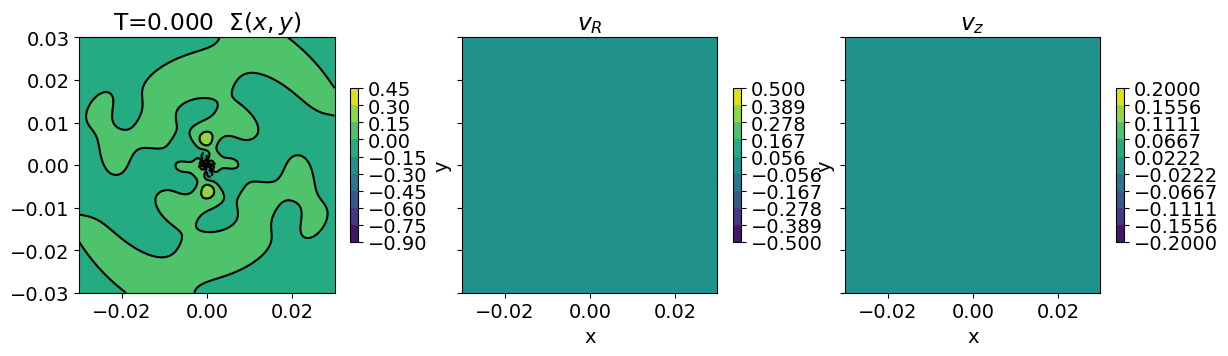

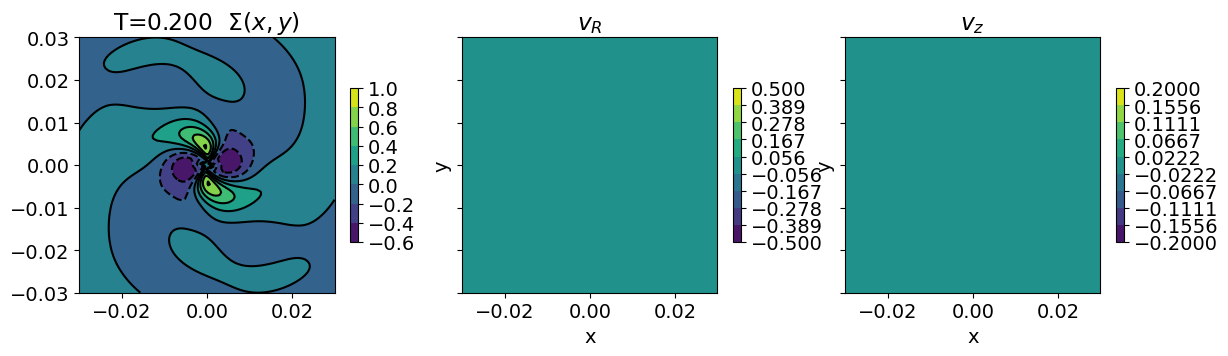

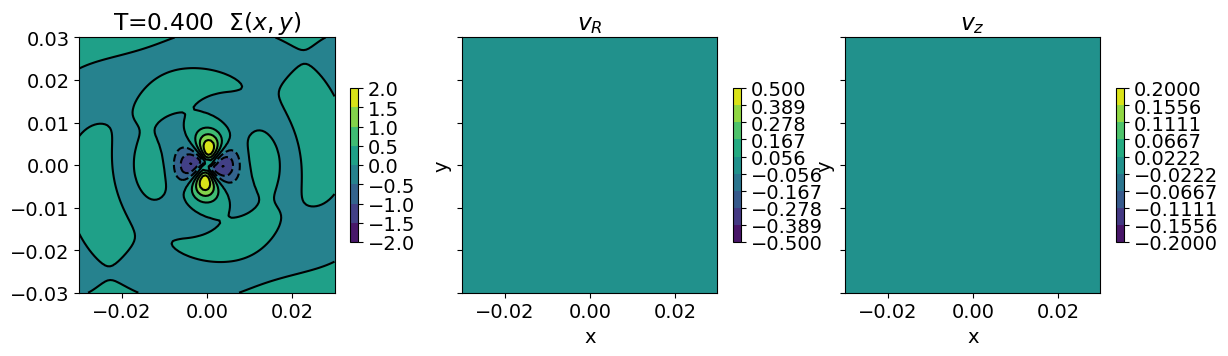

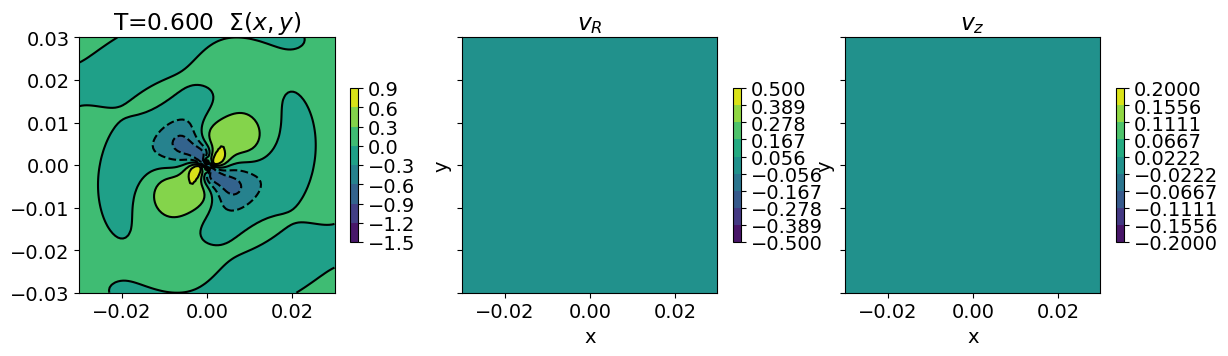

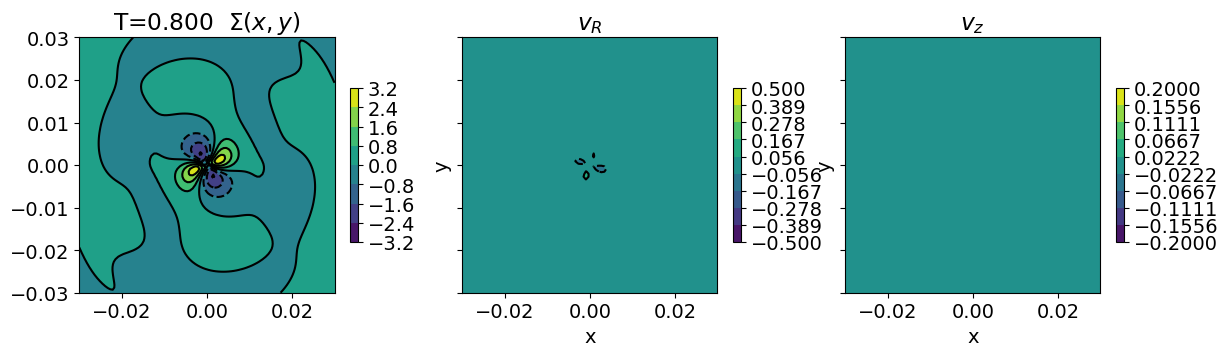

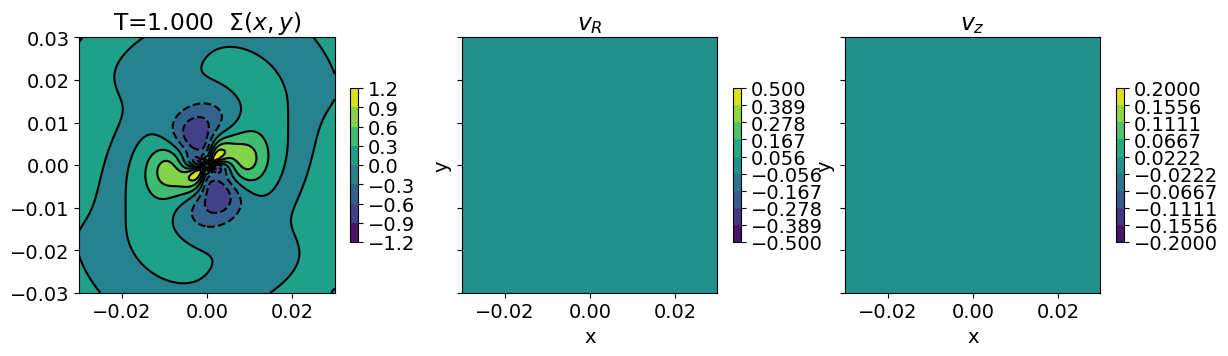

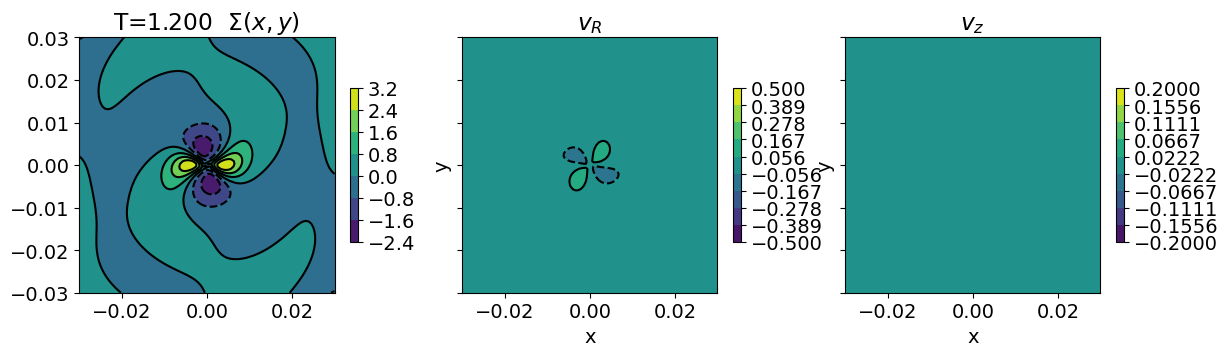

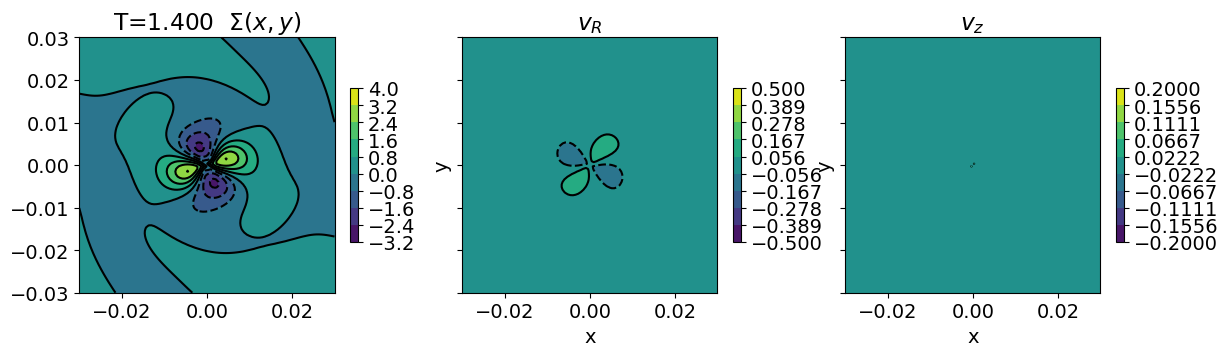

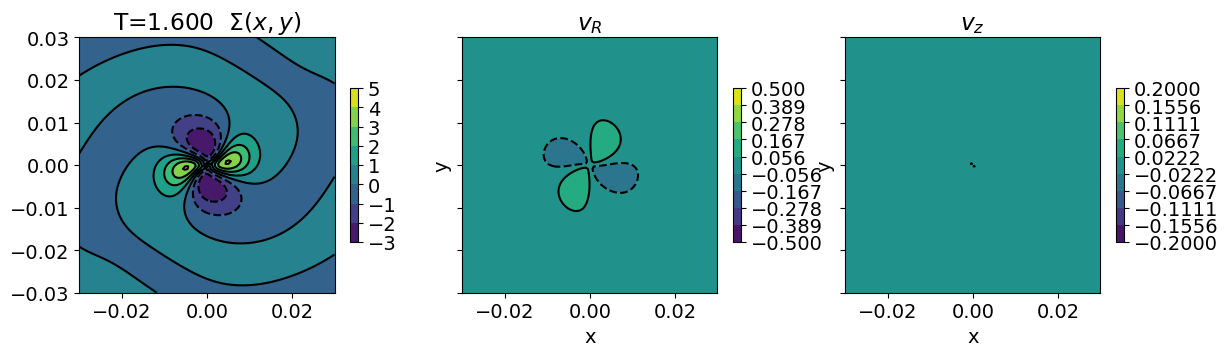

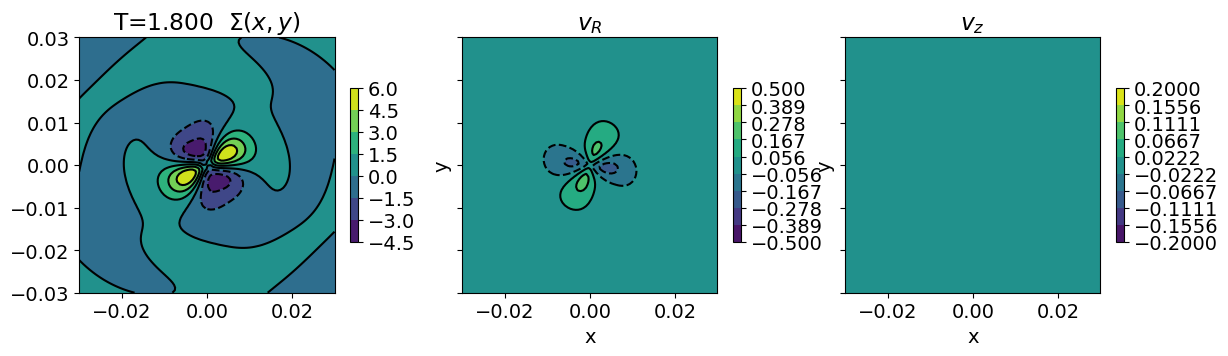

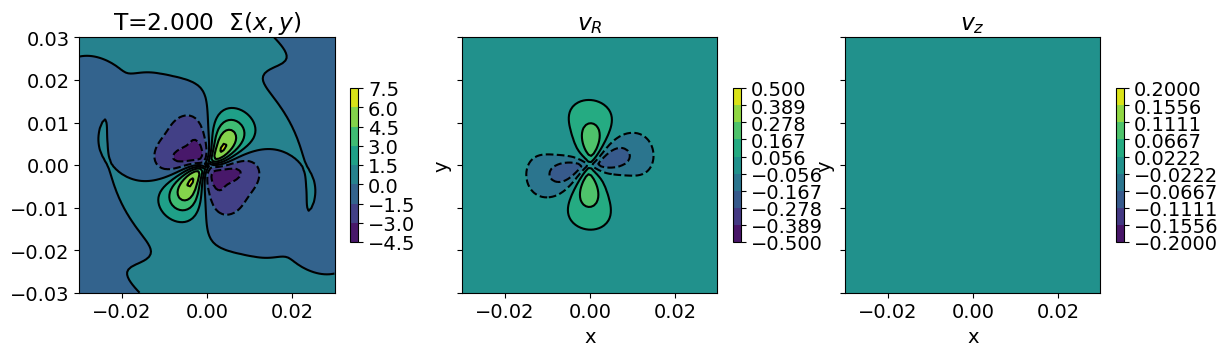

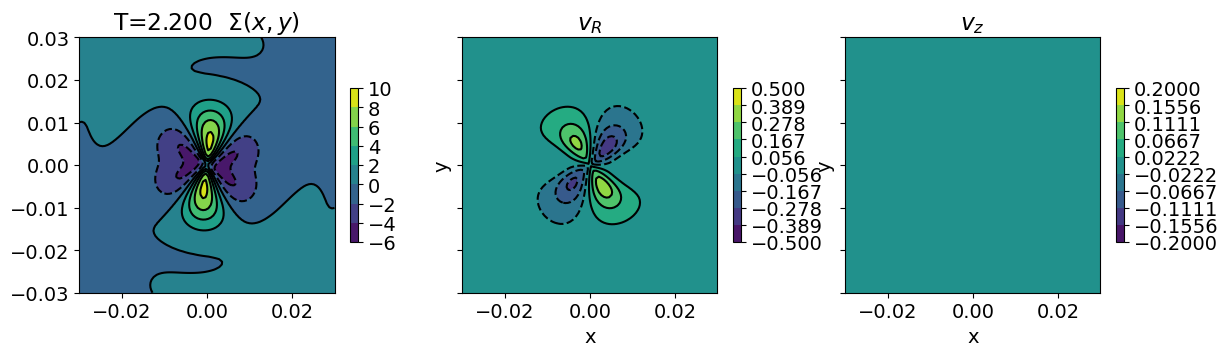

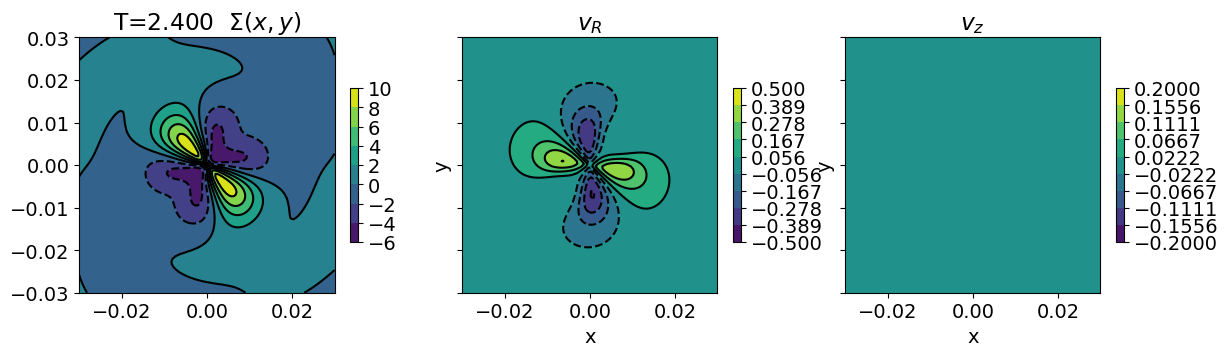

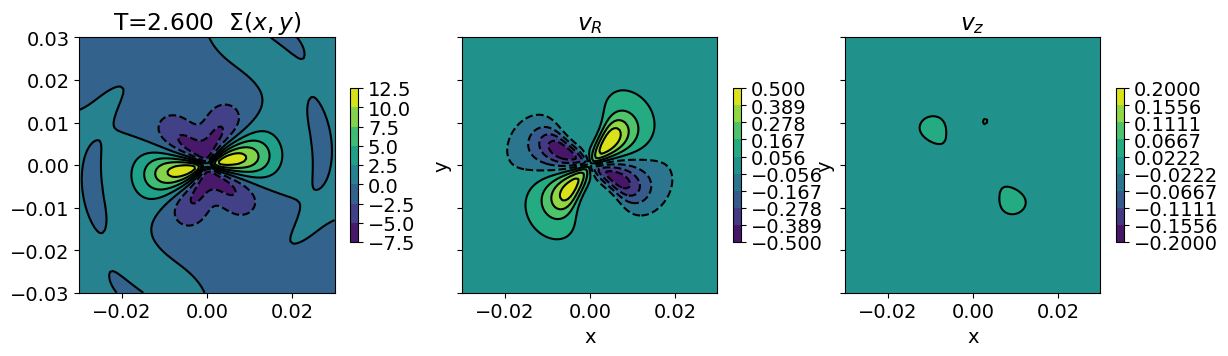

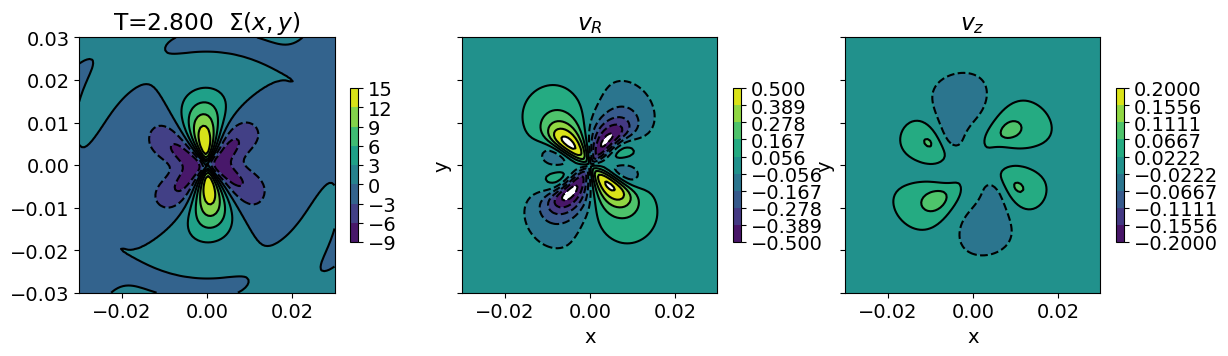

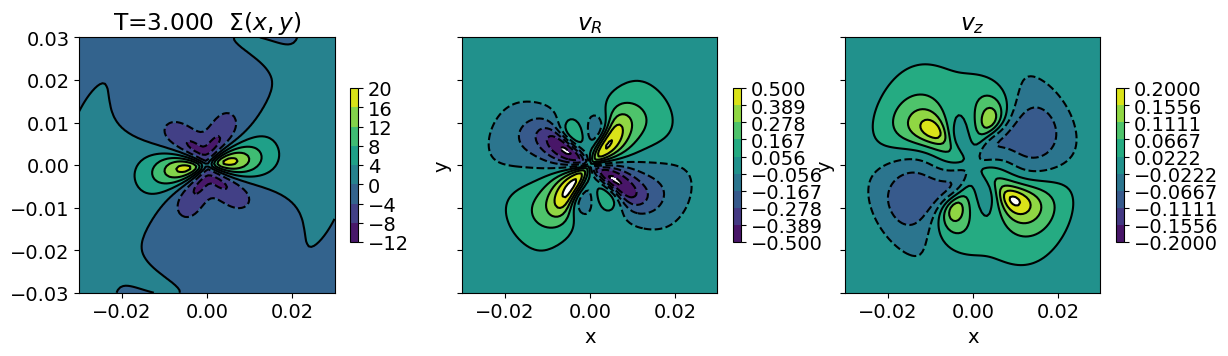

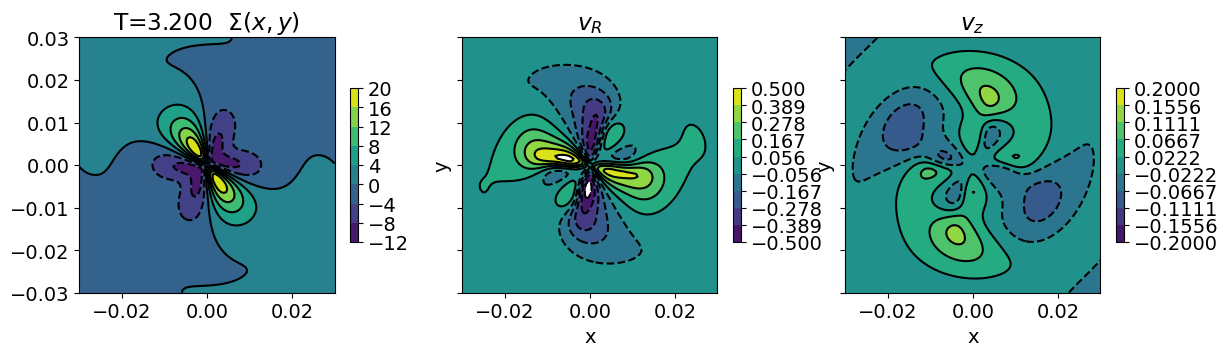

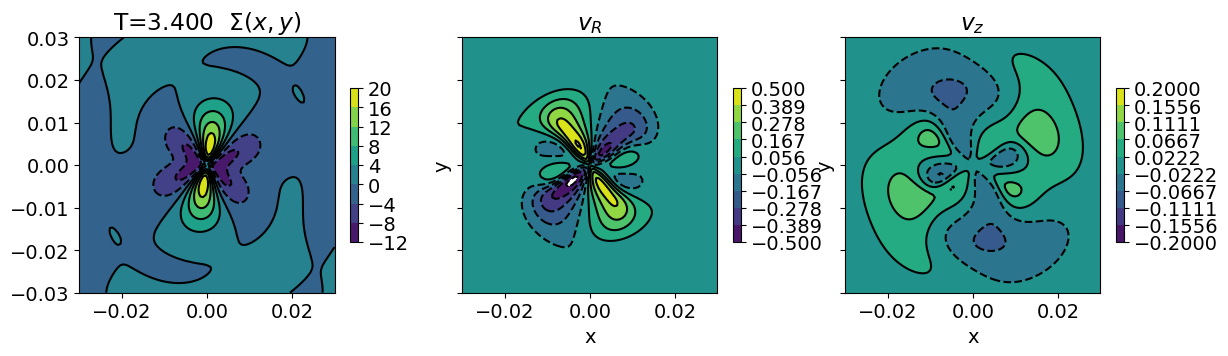

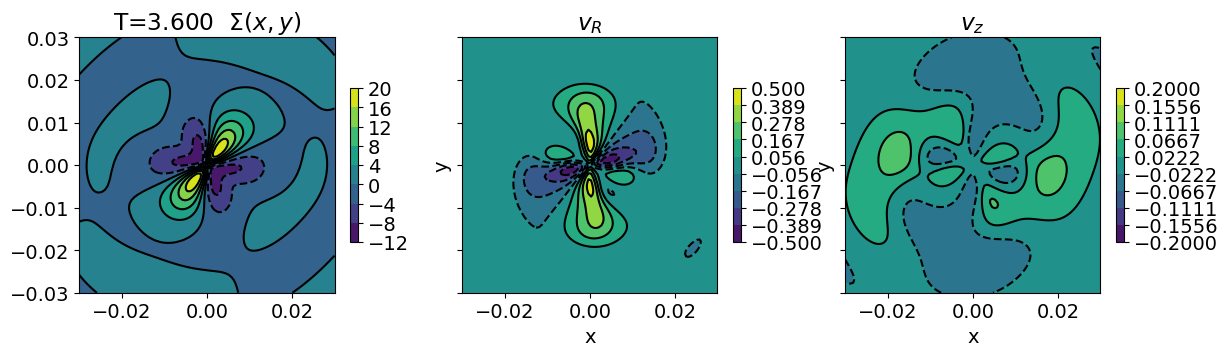

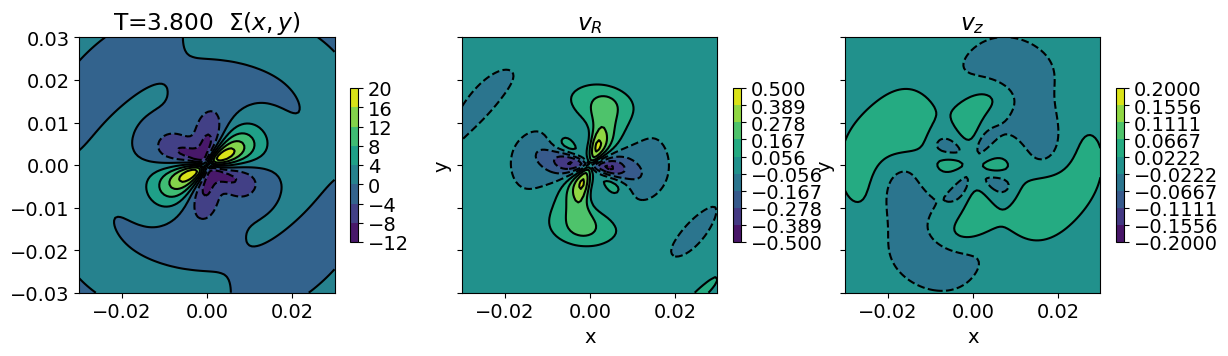

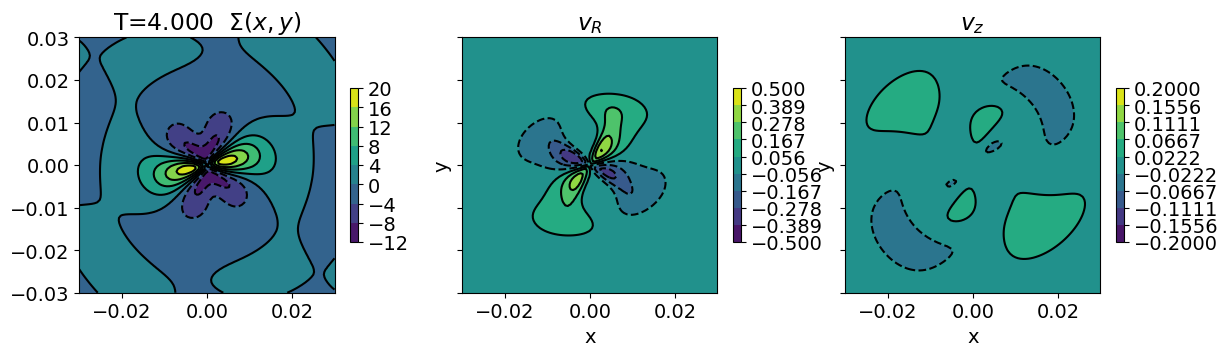

In [13]:
key1 = 'v_R'
key2 = 'v_z'
nx = 100
ny = 100

# Make the mesh
x = np.linspace(-rmax, rmax, nx)
y = np.linspace(-rmax, rmax, ny)
xv, yv = np.meshgrid(x, y)

for tim in vcoefs.Times():
    fig, ax = plt.subplots(1, 3, sharex='all', sharey='all', figsize=(14,4))
    for v in ax: 
        v.set_aspect('auto')
        v.set_box_aspect(1)
    
    mat1 = vsurfaces[tim][key1]/vsurfaces0[tim]['density']
    mat2 = vsurfaces[tim][key2]/vsurfaces0[tim]['density']
    
    v1 = np.linspace(-0.5, 0.5, 10, endpoint=True)
    v2 = np.linspace(-0.2, 0.2, 10, endpoint=True)


    cont1 = ax[1].contour(xv, yv, mat1.transpose(), levels=v1, colors='k')
    cont2 = ax[1].contourf(xv, yv, mat1.transpose(), levels=v1)
    plt.colorbar(cont2, ax=ax[1], shrink=0.5)
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    ax[1].set_title('${}$'.format(key1))

    cont3 = ax[2].contour(xv, yv, mat2.transpose(), levels=v2, colors='k')
    cont4 = ax[2].contourf(xv, yv, mat2.transpose(), levels=v2)
    plt.colorbar(cont4, ax=ax[2], shrink=0.5)
    ax[2].set_xlabel('x')
    ax[2].set_ylabel('y')
    ax[2].set_title('${}$'.format(key2))
    
    mat3 = vsurfaces[tim]['density']
    cont5 = ax[0].contour(xv, yv, mat3.transpose(), colors='k')
    cont6 = ax[0].contourf(xv, yv, mat3.transpose())
    plt.colorbar(cont6, ax=ax[0], shrink=0.5)
    ax[0].set_title(r'T={:4.3f}  $\Sigma(x, y)$'.format(tim))
    plt.show()

## Visualize the halo velocity field

In [14]:
halo_config = yaml_db['Output'][4]
halo_config['id'] = 'velocity'
# remove unwanted keys
if 'nint' in halo_config['parameters'].keys(): del halo_config['parameters']['nint']
if 'name' in halo_config['parameters'].keys(): del halo_config['parameters']['name']
print(yaml.dump(halo_config))

id: velocity
parameters:
  dof: 3
  lmax: 4
  model: file
  modelname: veltest.model
  nmax: 10



In [15]:
# Make the hao velocity basis
halo_basis  = pyEXP.basis.Basis.factory(yaml.dump(halo_config))

FieldBasis::orthoTest: worst=1.87958e-15


In [16]:
halo_file   = 'velcoef.dark.run2'
halo_coefs0 = pyEXP.coefs.Coefs.factory(halo_file, 1)
halo_coefs  = halo_coefs0.deepcopy()
htimes      = halo_coefs0.Times()
halo_data   = halo_coefs0.getAllCoefs()

In [17]:
# Let's zero all of the odd order data

for T in htimes:
    data = halo_coefs0(T)
    new_data = np.zeros(data.shape, dtype=data.dtype)
    for k in range(halo_data.shape[1]):
        l = int(0.5*(-1.0 + (1.0 + 8.0*k)**0.5))
        m = k - int(l * (l + 1) / 2)
        if l>0 and l%2==0 and m%2==0: 
            new_data[:,k,:] += data[:,k,:]
    halo_coefs.setMatrix(T, new_data)

In [18]:
rmin  = -0.02
rmax  =  0.02
ngrd  = 60
pmin  = [ rmin, rmin, rmin]
pmax  = [ rmax, rmax, rmax]
grid  = [ ngrd, ngrd, ngrd]

# Only render the final time
halo_fields = pyEXP.field.FieldGenerator(htimes[-1:], pmin, pmax, grid)

halo_volumes  = halo_fields.volumes(halo_basis, halo_coefs )
halo_volumes0 = halo_fields.volumes(halo_basis, halo_coefs0)

In [19]:
import k3d

v = halo_volumes[htimes[-1]]['v_r']/halo_volumes0[htimes[-1]]['density']

dmin = np.min(v)
dmax = np.max(v)

print('Field range', dmin, dmax)

# levels for rendering 
drange = (dmax - dmin)/6
levs = np.arange(dmin, dmax+0.01*drange, drange)

print("Level surfaces:", levs)

plot2 = k3d.plot(axes=['z', 'y', 'x'])
color_map = k3d.basic_color_maps.Jet

for lev in levs:
    plot2 += k3d.marching_cubes(v, level=lev, attribute=[lev], color_map=color_map, color_range=[levs[0], levs[-1]],
                            opacity=0.25,
                            xmin=rmin, xmax=rmax,
                            ymin=rmin, ymax=rmax,
                            zmin=rmin, zmax=rmax,
                            compression_level=9,
                            flat_shading=False)
plot2.display()
plot2.camera = [0.01, 0.01, 0.01, 0.0, 0.0, 0.0, 1, 0, 0]

Field range -0.040529154 0.054465007
Level surfaces: [-0.04052915 -0.02469679 -0.00886444  0.00696792  0.02280028  0.03863264
  0.054465  ]


Output()


***

## Where do you want to go next?

- [Return to Table of Contents](../README.ipynb)
- [Back to previous notebook](../Orbits/orbits%20with%20a%20custom%20force.ipynb)
- [Go to next notebook](cube%20run.ipynb)
